## **TELECOM CHURN PREDICTOR - MODEL EXPERIMENTATION**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [16]:
df=pd.read_csv("C:/Users/chiboy/telecom_churn_project/data/processed/telecom_churn_cleaned.csv")

### DATA PREPOCESSING

In [17]:
# 1. Prepare features and target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [18]:
# 2. Handle categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

C:\Users\chiboy\AppData\Local\Temp\ipykernel_75228\1802314722.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


In [19]:
# 3. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# 4. Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# 5. Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Train shape: {X_train_resampled.shape}")
print(f"After SMOTE - Churn: {y_train_resampled.mean():.2%}")

After SMOTE - Train shape: (8260, 21)
After SMOTE - Churn: 50.00%


### MODEL TRAINING

In [22]:
# 1. Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

In [23]:
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'model': model,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'predictions': y_pred,
        'probabilities': y_proba,
        'classification_report': classification_report(y_test, y_pred)
    }
    
    print(f"ROC-AUC: {results[name]['roc_auc']:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))


Training Logistic Regression...
ROC-AUC: 0.8314
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

[[738 295]
 [ 81 293]]

Training Random Forest...
ROC-AUC: 0.8153
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.78      1407

[[868 165]
 [152 222]]

Training XGBoost...
ROC-AUC: 0.8143
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.57      0.57      0.57       374

    acc

In [24]:
# 2. Select best model
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']
print(f" Best Model: {best_name} (ROC-AUC: {results[best_name]['roc_auc']:.4f})")

 Best Model: Logistic Regression (ROC-AUC: 0.8314)


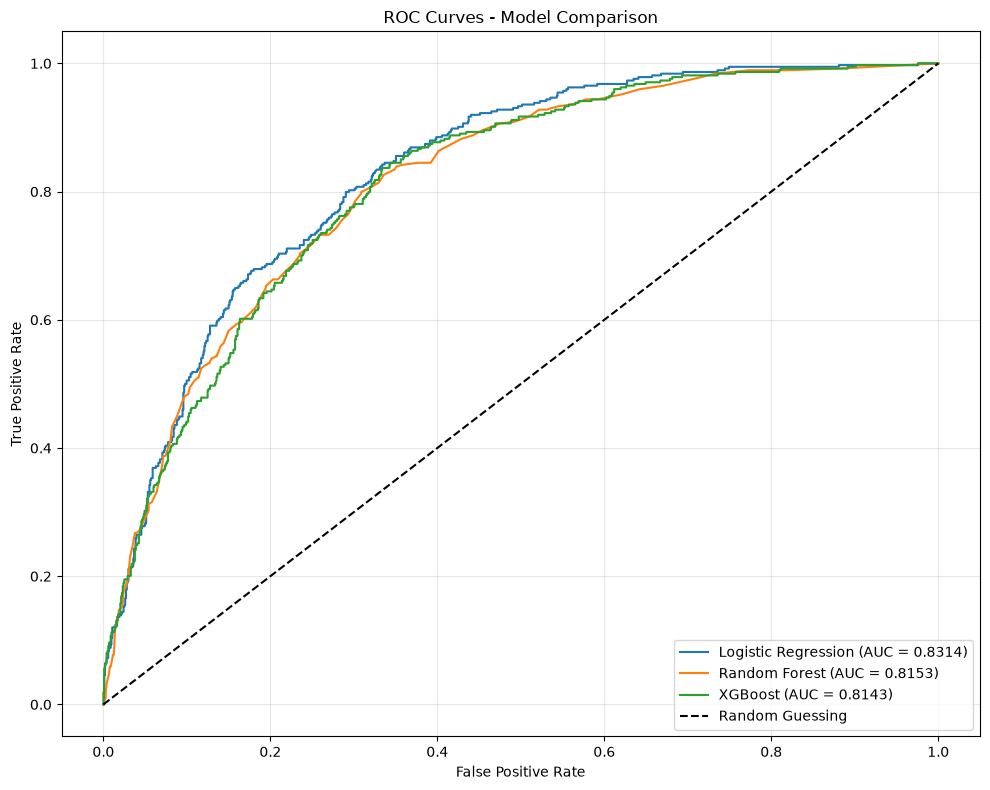

In [25]:
# ROC Curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/model_roc_curves.png', dpi=300)
plt.show();

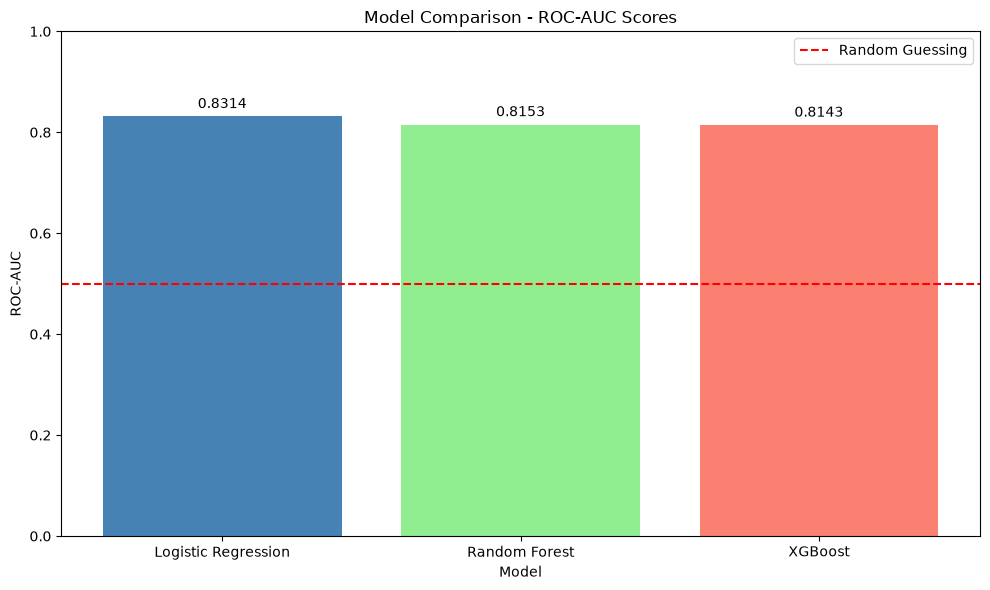

In [26]:
# Model comparison bar chart
plt.figure(figsize=(10, 6))
names = list(results.keys())
aucs = [results[name]['roc_auc'] for name in names]
bars = plt.bar(names, aucs, color=['steelblue', 'lightgreen', 'salmon'])
plt.axhline(y=0.5, color='red', linestyle='--', label='Random Guessing')
plt.ylim(0, 1)
plt.title('Model Comparison - ROC-AUC Scores')
plt.ylabel('ROC-AUC')
plt.xlabel('Model')
plt.legend()
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{auc:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/model_comparison.png', dpi=300)
plt.show()

### HYPERPARAMETER TUNING

In [27]:
#7. TUNE XGBoost MODEL
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_resampled, y_train_resampled)

print(f"   Best parameters: {grid.best_params_}")
print(f"   Best CV ROC-AUC: {grid.best_score_:.4f}")

tuned_xgb = grid.best_estimator_
tuned_xgb.fit(X_train_resampled, y_train_resampled)
y_proba_tuned = tuned_xgb.predict_proba(X_test_scaled)[:, 1]
tuned_auc = roc_auc_score(y_test, y_proba_tuned)

print(f"   Tuned XGBoost test AUC: {tuned_auc:.4f}")


   Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
   Best CV ROC-AUC: 0.9382
   Tuned XGBoost test AUC: 0.8257


### FINAL MODEL CHOICE

In [28]:
# 8. SELECT FINAL MODEL
# Compare LR vs Tuned XGBoost
print("-"*40)
print(f"   Logistic Regression: {results['Logistic Regression']['roc_auc']:.4f}")
print(f"   Tuned XGBoost:       {tuned_auc:.4f}")

if results['Logistic Regression']['roc_auc'] >= tuned_auc:
    final_model = results['Logistic Regression']['model']
    final_auc = results['Logistic Regression']['roc_auc']
    print("\n   Final model: Logistic Regression")
else:
    final_model = tuned_xgb
    final_auc = tuned_auc
    print("\n   Final model: Tuned XGBoost")

print(f"   Final ROC-AUC: {final_auc:.4f}")

----------------------------------------
   Logistic Regression: 0.8314
   Tuned XGBoost:       0.8257

   Final model: Logistic Regression
   Final ROC-AUC: 0.8314
